<a href="https://colab.research.google.com/github/ariitooo/Building-a-Brain-Tumor-Detection-Using-Deep-Learning-MRI-Images-Detection-Using-Computer-Vision/blob/main/Building-a-Brain-Tumor-Detection-Using-Deep-Learning-MRI-Images-Detection-Using-Computer-Vision%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import numpy as np
import random
from PIL import Image , ImageEnhance
import matplotlib.pyplot as plt


#keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
import seaborn as sns



In [7]:
!unzip "/content/drive/MyDrive/Colab Notebooks/archive.zip"
train_dir = "/content/Training"
test_dir ="/content/Testing"
# train_dir = "/content/drive/MyDrive/MRI images/Training"
# test_dir ="/content/drive/MyDrive/MRI images/Testing"

train_paths = []
train_labels =[]
for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir,label)):
    train_paths.append(os.path.join(train_dir,label,image))
    train_labels.append(label)

train_paths,train_labels = shuffle(train_paths,train_labels)


test_paths = []
test_labels =[]
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir,label)):
    test_paths.append(os.path.join(test_dir,label,image))
    test_labels.append(label)

test_paths,test_labels = shuffle(test_paths,test_labels)

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

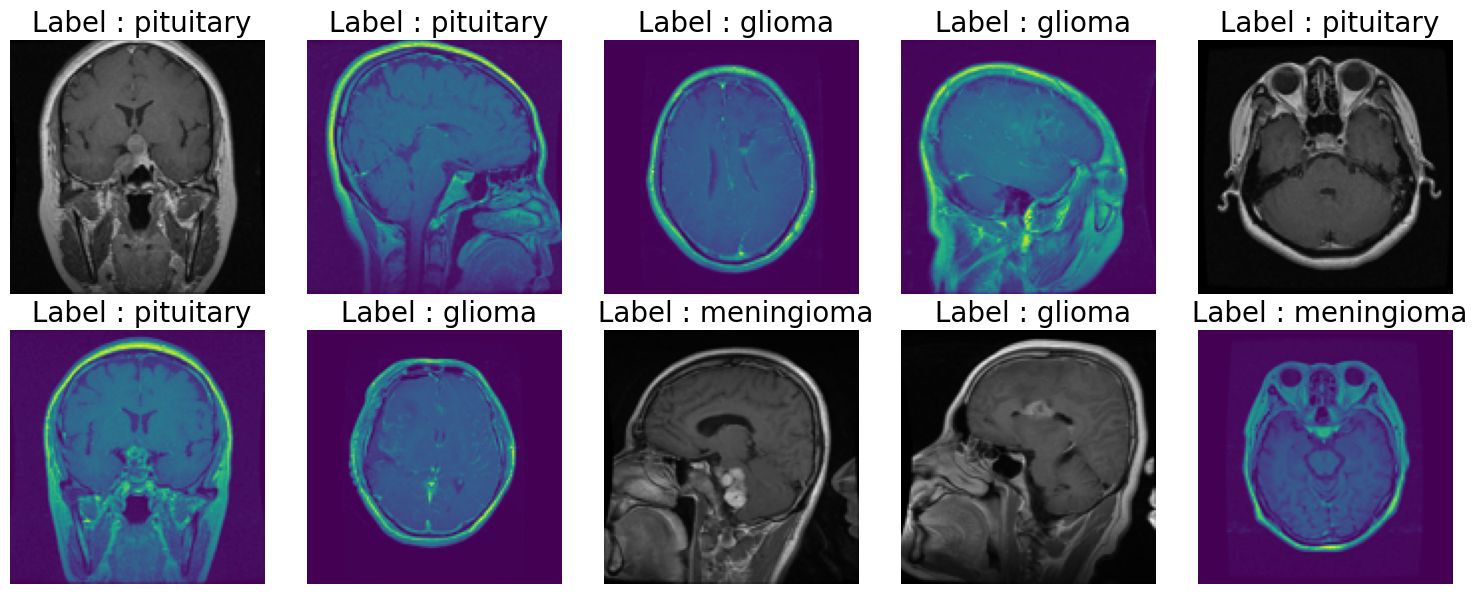

In [8]:
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes =plt.subplots(2,5 ,figsize=(15,6))
axes =axes.ravel()
for i,idx in enumerate(random_indices):
  img_path = train_paths[idx]
  img = Image.open(img_path)
  img = img.resize((128,128))
  axes[i].imshow(img)
  axes[i].axis ('off')
  axes[i].set_title(f" Label : {train_labels[idx]}" , fontsize =20)
plt.tight_layout()
plt.show()





In [9]:
import numpy as np

IMAGE_SIZE = 128

unique_labels = sorted(os.listdir(train_dir))

label_to_index = {label: i for i, label in enumerate(unique_labels)}







def augment_image(image):

    image = Image.fromarray(np.uint8(image))

    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))

    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))

    image = np.array (image) / 255.0

    return image



def open_images(paths):

    images = []

    for path in paths:

        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))

        image = augment_image(image)

        images.append(image)

    return np.array(images)



def encode_label(labels):

    unique_labels = os.listdir(train_dir)

    encoded = [unique_labels.index(label) for label in labels]

    return np.array(encoded)







def datagen(paths, labels, batch_size=12, epochs =1):



    for _ in range (epochs):

        for i in range(0, len(paths), batch_size):

            batch_paths = paths[i:i+batch_size]

            batch_images = open_images(batch_paths)

            batch_labels = labels[i:i+batch_size]

            batch_labels = encode_label(batch_labels)

            yield batch_images, batch_labels

In [10]:

IMAGE_SIZE =128

base_model =VGG16(input_shape = (IMAGE_SIZE,IMAGE_SIZE,3),include_top=False,weights='imagenet')



for layer in base_model.layers:

  layer.trainable = False



base_model.layers[-2].trainable =True

base_model.layers[-3].trainable =True

base_model.layers[-4].trainable =True





model =Sequential()

model.add(base_model)

model.add(Flatten())

model.add(Dropout(0.3))

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.2))

model.add(Dense(len(os.listdir(train_dir)),activation="softmax"))





model.compile(optimizer = Adam(learning_rate=0.0001),

              loss = 'sparse_categorical_crossentropy',

              metrics=['sparse_categorical_accuracy'])







batch_size = 20

steps = len(train_paths) // batch_size

epochs = 5



history = model.fit(

    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),

    epochs=epochs,

    steps_per_epoch=steps)

Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - loss: 0.4672 - sparse_categorical_accuracy: 0.8154
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - loss: 0.2417 - sparse_categorical_accuracy: 0.9121
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - loss: 0.1642 - sparse_categorical_accuracy: 0.9380
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - loss: 0.1268 - sparse_categorical_accuracy: 0.9518
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 17s 62ms/step - loss: 0.0883 - sparse_categorical_accuracy: 0.9666


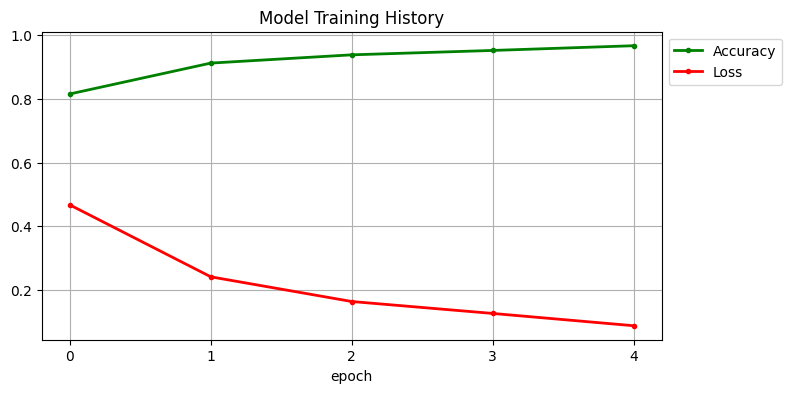

In [11]:
plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g', linestyle ="-", linewidth=2)
plt.plot(history.history['loss'], '.r',linestyle ="-", linewidth=2)
plt.title('Model Training History')
plt.xlabel ('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy' , 'Loss'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()


In [12]:
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)

print('Classification Report:')
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.72      0.82       400
           1       0.94      1.00      0.97       400
           2       0.98      0.98      0.98       400
           3       0.82      0.95      0.88       400

    accuracy                           0.91      1600
   macro avg       0.92      0.91      0.91      1600
weighted avg       0.92      0.91      0.91      1600



Confudion Matrics
[[290  24   6  80]
 [  0 399   0   1]
 [  1   1 394   4]
 [ 17   1   3 379]]


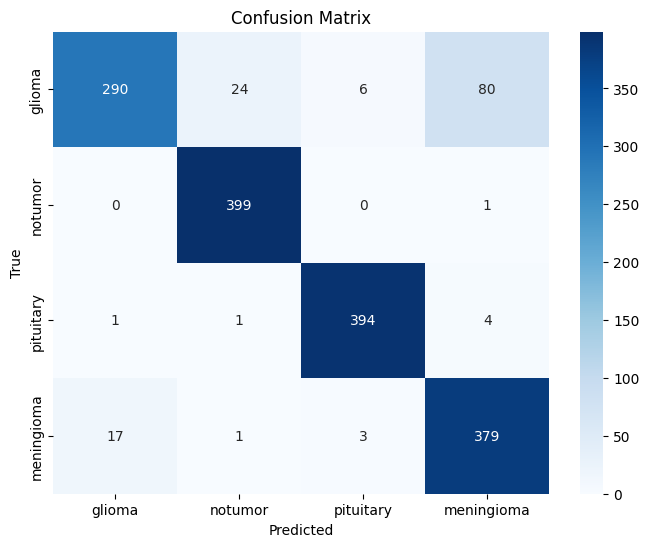

In [13]:
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confudion Matrics")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=os.listdir(train_dir), yticklabels=os.listdir(test_dir))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()